In [1]:
import sys 
sys.path.append("../src")
from data_loader import  (load_prices, compute_hedge_ratio, compute_spread, compute_zscore, generate_signals, compute_pnl_with_costs, sharpe_ratio, max_drawdown,compute_correlation, find_cointegrated_pairs)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = load_prices()
print("Shape : " , prices.shape)
print("Data range : " , prices.index[0].date(), "to" , prices.index[-1].date())

Shape :  (1509, 41)
Data range :  2018-01-02 to 2023-12-29


In [2]:
# define train and test splits

# train period : 2018 - 2021
train_prices = prices["2018-01-01" : "2021-12-31"]

# test period : 2022 - 2023
test_prices = prices["2022-01-01" : "2023-12-31"]

print("Train period:")
print(f"  Shape : {train_prices.shape}")
print(f"  From : {train_prices.index[0].date()}")
print(f"  To  : {train_prices.index[-1].date()}")

print("\n Test Period")
print(f"  Shape : {test_prices.shape}")
print(f"  From  : {test_prices.index[0].date()}")
print(f"  To    : {test_prices.index[-1].date()}")

print(f"\nTrain/Test Ratio : {len(train_prices)} / {len(test_prices)}")

Train period:
  Shape : (1008, 41)
  From : 2018-01-02
  To  : 2021-12-31

 Test Period
  Shape : (501, 41)
  From  : 2022-01-03
  To    : 2023-12-29

Train/Test Ratio : 1008 / 501


In [7]:
# find pairs on training data only

corr_matrix,pairs_df = compute_correlation(train_prices, threashold = 0.8)
coint_df = find_cointegrated_pairs(train_prices , pairs_df)
train_pairs = coint_df[coint_df["cointegrated"] == True].reset_index(drop=True)

print(f"Pairs found on training data : {len(train_pairs)}")
print(train_pairs[["ticker_1", "ticker_2","coint_pvalue"]])

Pairs found on training data : 21
   ticker_1 ticker_2  coint_pvalue
0      META      TGT      0.001777
1        MA      WMT      0.003089
2         V      WMT      0.004086
3     GOOGL      UNH      0.006042
4       JNJ      TGT      0.006235
5       ABT      JNJ      0.012769
6        CL      WMT      0.013557
7       JNJ     MSFT      0.015999
8        KR      UNH      0.017131
9         C       GE      0.018694
10     AMZN      JNJ      0.019975
11      JNJ      UNH      0.025479
12     AMZN       CL      0.026618
13      CVX      WFC      0.027877
14      GIS       MA      0.033329
15      CAT       DE      0.036924
16      JNJ       KR      0.037050
17       MA        V      0.037295
18      ABT       CL      0.041813
19      JNJ     PYPL      0.048365
20       CL        V      0.048555


In [8]:
#  run full strategy on train period and test period separately
def run_strategy_on_period(prices_period , ticker_1, ticker_2):
    try: 
        beta , intercept = compute_hedge_ratio(prices_period ,ticker_1 ,ticker_2)
        spread = compute_spread(prices_period , ticker_1 ,ticker_2 , beta , intercept)
        zscore = compute_zscore(spread)
        signals = generate_signals(zscore)
        pnl = compute_pnl_with_costs(prices_period , ticker_1 , ticker_2 , beta , signals)

        sharpe = sharpe_ratio(pnl)
        mdd = max_drawdown(pnl)
        total_ret = round((pnl.sum() / 10000) * 100 , 2)
        trades = int((signals.diff().abs() > 0).sum() /2)

        return {
            "ticker_1" : ticker_1,
            "ticker_2" : ticker_2,
            "total_return_pct" : total_ret,
            "sharpe" : sharpe, 
            "max_drawdown_pct" : mdd ,
            "trade" : trades
        } 
    
    except Exception as e:
        return None
    
# run top 5 training pairs on both periods
top_pairs = train_pairs.head(5)

train_result = []
test_result = []

for _, row in top_pairs.iterrows():
    t1, t2 = row["ticker_1"], row["ticker_2"]

    train_res = run_strategy_on_period(train_prices,t1,t2)
    test_res = run_strategy_on_period(test_prices,t1,t2)

    if train_res:
        train_res["period"] = "train"
        train_result.append(train_res)

    if test_res:
        test_res["period"] = "test"
        test_result.append(test_res)

train_df = pd.DataFrame(train_result)
test_df = pd.DataFrame(test_result)

print("TRAIN RESULTS (2018-2021):")
print(train_df[["ticker_1", "ticker_2", "total_return_pct", "sharpe", "max_drawdown_pct"]])
print("\nTEST RESULTS (2022-2023):")
print(test_df[["ticker_1", "ticker_2", "total_return_pct", "sharpe", "max_drawdown_pct"]])

TRAIN RESULTS (2018-2021):
  ticker_1 ticker_2  total_return_pct  sharpe  max_drawdown_pct
0     META      TGT             54.33  1.0129            -13.99
1       MA      WMT             17.80  0.3632            -15.30
2        V      WMT             17.10  0.4010            -14.49
3    GOOGL      UNH             21.89  0.5586            -16.78
4      JNJ      TGT            -28.94 -0.6474            -42.42

TEST RESULTS (2022-2023):
  ticker_1 ticker_2  total_return_pct  sharpe  max_drawdown_pct
0     META      TGT            -55.93 -1.3989            -72.58
1       MA      WMT              4.20  0.3046             -8.14
2        V      WMT              2.18  0.1832             -7.31
3    GOOGL      UNH             15.66  0.6794            -11.91
4      JNJ      TGT             -4.74 -0.2039            -14.61


In [13]:
# build a robustness filter
# Pairs that pass training but fail test are useless. 
# Add a filter that only keeps pairs where test Sharpe > 0.

comparison = train_df.merge(test_df , on=["ticker_1","ticker_2"] , suffixes = ("_train", "_test"))

# robustness filter - test Sharpe must be positive
robust_pairs = comparison[comparison["sharpe_test"] > 0].reset_index(drop=True)

print("All pairs comparision: ")
print(comparison[["ticker_1","ticker_2" , "sharpe_train" ,"sharpe_test" , "total_return_pct_train" , "total_return_pct_test"]].to_string())

print(f"\n Robust pairs (positive test Sharpe) : {len(robust_pairs)}")
print(robust_pairs[["ticker_1" , "ticker_2" , "sharpe_train" , "sharpe_test"]])


All pairs comparision: 
  ticker_1 ticker_2  sharpe_train  sharpe_test  total_return_pct_train  total_return_pct_test
0     META      TGT        1.0129      -1.3989                   54.33                 -55.93
1       MA      WMT        0.3632       0.3046                   17.80                   4.20
2        V      WMT        0.4010       0.1832                   17.10                   2.18
3    GOOGL      UNH        0.5586       0.6794                   21.89                  15.66
4      JNJ      TGT       -0.6474      -0.2039                  -28.94                  -4.74

 Robust pairs (positive test Sharpe) : 3
  ticker_1 ticker_2  sharpe_train  sharpe_test
0       MA      WMT        0.3632       0.3046
1        V      WMT        0.4010       0.1832
2    GOOGL      UNH        0.5586       0.6794


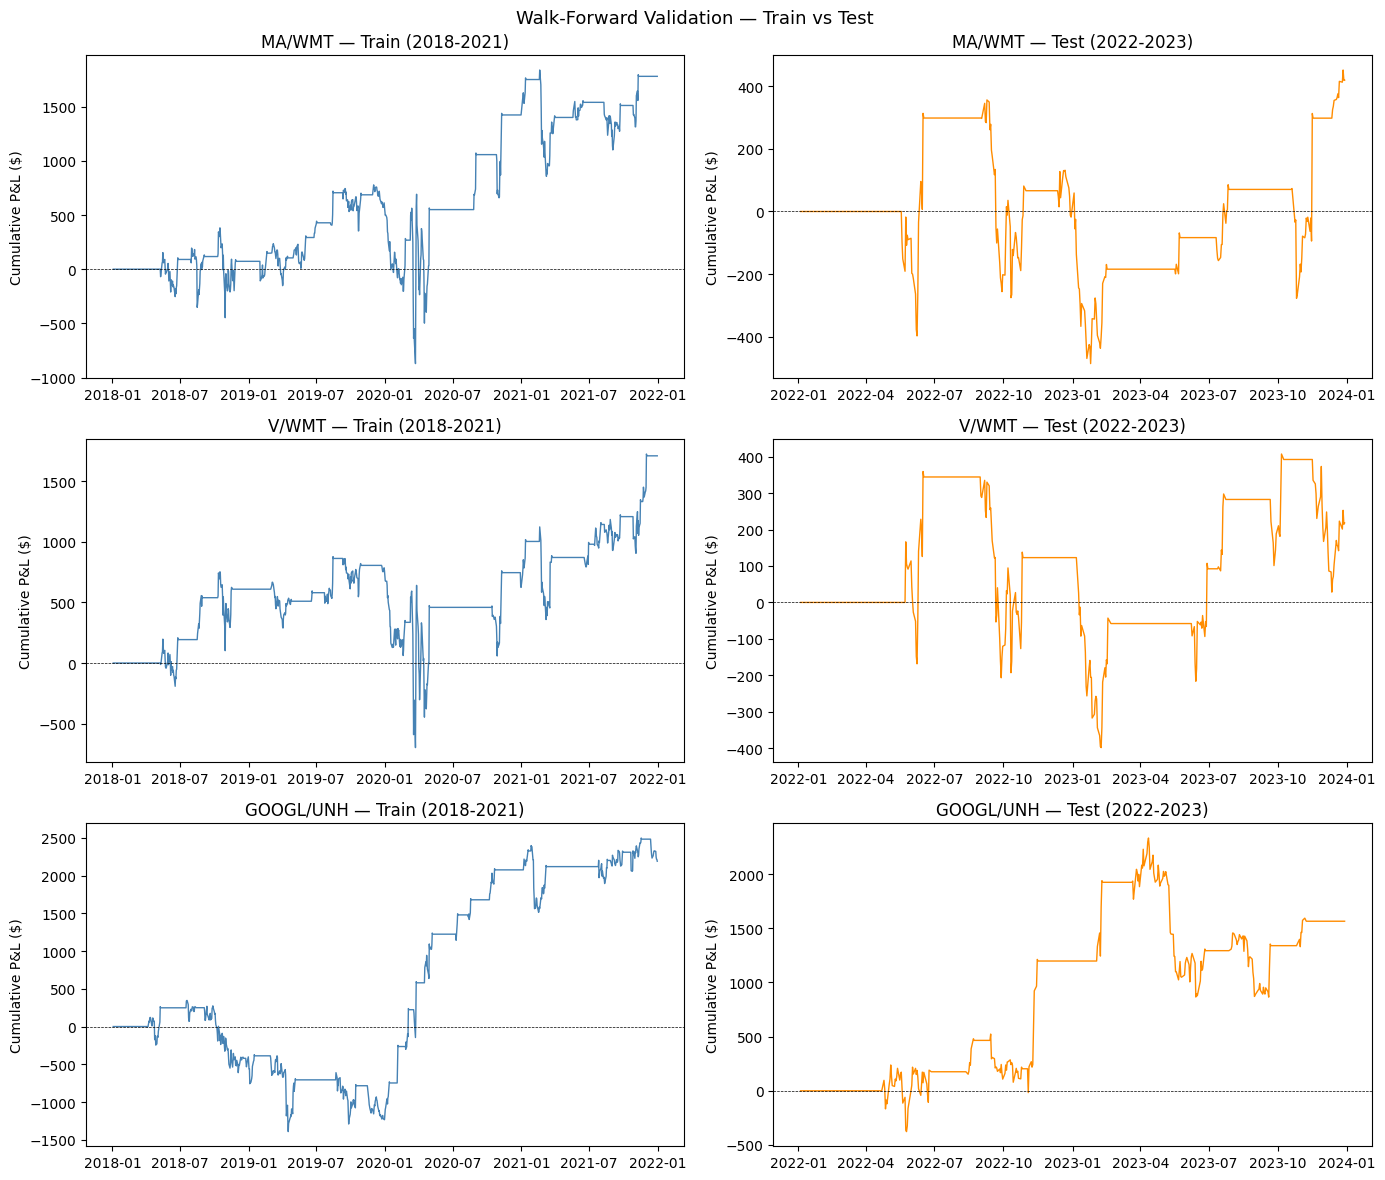

In [ ]:
#  plot train vs test cumulative returns

fig , axes = plt.subplots(3,2, figsize = (14,12))
axes = axes.flatten()

robust_list = [("MA" , "WMT"), ("V", "WMT"), ("GOOGL", "UNH")]

for i ,(t1,t2) in enumerate(robust_list):
    # train 
    beta_tr, int_tr = compute_hedge_ratio(train_prices, t1, t2)
    spread_tr = compute_spread(train_prices, t1, t2, beta_tr, int_tr)
    zscore_tr = compute_zscore(spread_tr)
    signals_tr = generate_signals(zscore_tr)
    pnl_tr = compute_pnl_with_costs(train_prices, t1, t2, beta_tr, signals_tr)

    # test
    beta_te, int_te = compute_hedge_ratio(test_prices, t1, t2)
    spread_te = compute_spread(test_prices, t1, t2, beta_te, int_te)
    zscore_te = compute_zscore(spread_te)
    signals_te = generate_signals(zscore_te)
    pnl_te = compute_pnl_with_costs(test_prices, t1, t2, beta_te, signals_te)

    # plot train
    axes[i*2].plot(pnl_tr.index, pnl_tr.cumsum(), color="steelblue", linewidth=1)
    axes[i*2].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[i*2].set_title(f"{t1}/{t2} — Train (2018-2021)")
    axes[i*2].set_ylabel("Cumulative P&L ($)")

    # plot test
    axes[i*2+1].plot(pnl_te.index, pnl_te.cumsum(), color="darkorange", linewidth=1)
    axes[i*2+1].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[i*2+1].set_title(f"{t1}/{t2} — Test (2022-2023)")
    axes[i*2+1].set_ylabel("Cumulative P&L ($)")

plt.suptitle("Walk-Forward Validation — Train vs Test", fontsize=13)
plt.tight_layout()
plt.savefig("../data/walkforward_results.png", dpi=120)
plt.show()

In [15]:
comparison.to_csv("../data/walkforward_comparison.csv" , index = False)
robust_pairs.to_csv("../data/robust_pairs.csv" , index = False)

print("Saved walkforward results.")
print("Robust pairs:")
print(robust_pairs[["ticker_1","ticker_2" , "sharpe_train","sharpe_test"]])


Saved walkforward results.
Robust pairs:
  ticker_1 ticker_2  sharpe_train  sharpe_test
0       MA      WMT        0.3632       0.3046
1        V      WMT        0.4010       0.1832
2    GOOGL      UNH        0.5586       0.6794
